In [9]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def build_exp_paths(root_data_dir, experiments):
    exp_paths = {}
    for exp in experiments:
        branch = "er" if exp.endswith("_er") else "sj"
        exp_paths[exp] = os.path.join(root_data_dir, branch, exp)
    return exp_paths

def plot_cluster_size(exp_paths):
    code_to_gamma = {
        "0001": 0.001,
        "0005": 0.005,
        "001":  0.01,
        "005":  0.05,
        "01":   0.1,
    }
    gamma_order = [str(v) for v in code_to_gamma.values()]

    rows = []
    for exp, base in exp_paths.items():
        out = os.path.join(base, "output")
        tag2 = "er" if exp.endswith("_er") else "sj"
        ss   = "noss" if "no_ss" in exp else "ss"
        env  = "ra"   if "_ra_"  in exp else "sa"

        for code, gamma in code_to_gamma.items():
            fp = os.path.join(out, f"clustering_metrics_{code}.csv")
            df = pd.read_csv(fp, usecols=["size"])
            df["gamma"] = str(gamma)
            df["tag2"]  = tag2
            df["ss"]    = ss
            df["env"]   = env
            rows.append(df)

    big = pd.concat(rows, ignore_index=True)
    big["gamma"] = pd.Categorical(big["gamma"], categories=gamma_order, ordered=True)

    sns.set_style("whitegrid")
    palette = {"er":"#EF5350", "sj":"#42A5F5"}

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    facets = [
        ("ra", "noss"),
        ("ra", "ss"),
        ("sa", "noss"),
        ("sa", "ss"),
    ]
    for ax, (env, ss) in zip(axes.flatten(), facets):
        sub = big[(big.env==env)&(big.ss==ss)]
        sns.boxplot(
            data=sub,
            x="gamma", y="size", hue="tag2",
            order=gamma_order,
            hue_order=["er","sj"],
            palette=palette,
            fliersize=2,    
            linewidth=1,
            ax=ax,
        )

        ax.set_ylim(0, 4000)
        ax.grid(axis="y", which="major", linestyle="--", alpha=0.5)
        ax.get_legend().remove()

    

    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="graph type",
        loc="center left",             
        bbox_to_anchor=(0.8, 0.5),       
        borderaxespad=0.3
    )



    fig.text(0.5, 0.04, "Leiden CPM Resolution Value", ha="center")
    fig.text(0.04, 0.5, "Cluster Size", va="center", rotation="vertical")
    for row_idx, env in enumerate(["ra","sa"]):
        ax = axes[row_idx, 1]
        ax.annotate(
            text=env,
            xy=(1.15, 0.5),
            xycoords="axes fraction",
            ha="left", va="center",
            fontsize=14, fontweight="bold"
        )


    for col_idx, ss in enumerate(["noss","ss"]):
        ax = axes[0, col_idx]
        ax.annotate(
            text=ss,
            xy=(0.5, 1.15),
            xycoords="axes fraction",
            ha="center", va="bottom",
            fontsize=14, fontweight="bold"
        )

    plt.tight_layout(rect=[0.05, 0.05, 0.88, 0.95])
    plt.show()

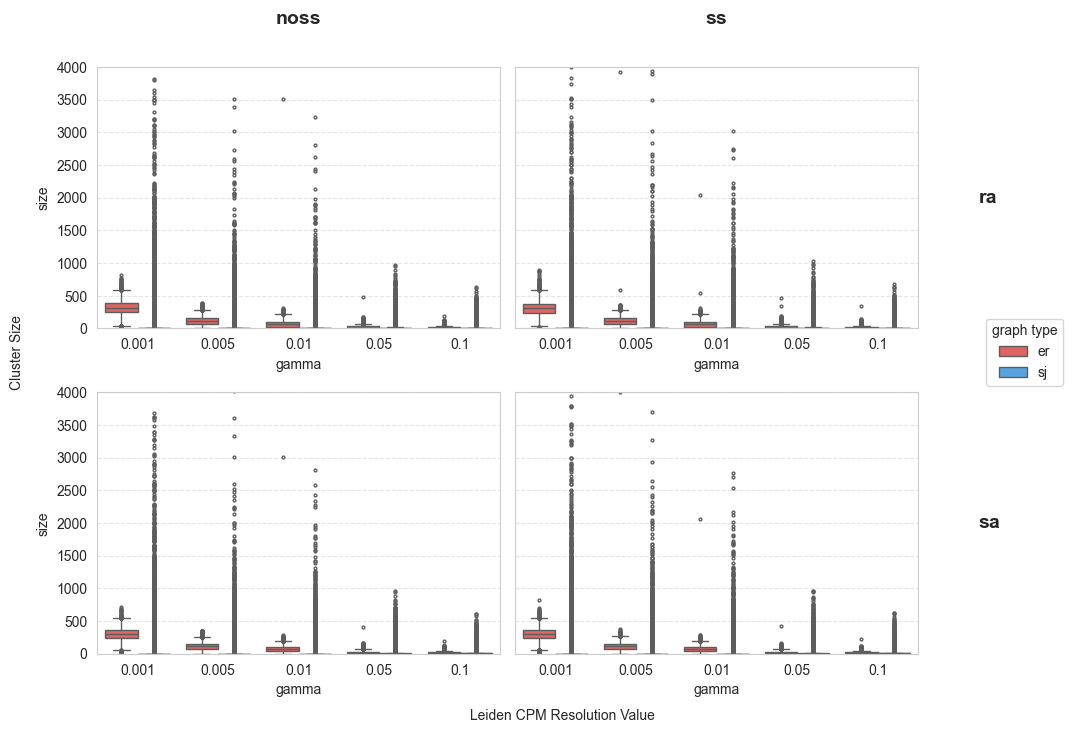

In [53]:

root = "data"

#  • Lista exata dos 8 experimentos
experiments = [
    "7_6_fmf_standard_no_ss_ra_new_pubmed",
    "7_6_fmf_standard_no_ss_sa_new_pubmed",
    "7_6_fmf_standard_ss_ra_new_pubmed",
    "7_6_fmf_standard_ss_sa_new_pubmed",
    "7_7_ecc7_no_ss_ra_new_pubmed_er",
    "7_7_ecc7_no_ss_sa_new_pubmed_er",
    "7_7_ecc7_ss_ra_new_pubmed_er",
    "7_7_ecc7_ss_sa_new_pubmed_er",
]

exp_paths = build_exp_paths(root, experiments)
plot_cluster_size(exp_paths)


In [ ]:
def build_exp_paths(root_data_dir, experiments):
    exp_paths = {}
    for exp in experiments:
        branch = "er" if exp.endswith("_er") else "sj"
        exp_paths[exp] = os.path.join(root_data_dir, branch, exp)
    return exp_paths

def plot_cluster_mincut(exp_paths):

    code_to_gamma = {
        "0001": 0.001,
        "0005": 0.005,
        "001":  0.01,
        "005":  0.05,
        "01":   0.1,
    }
    gamma_order = [str(v) for v in code_to_gamma.values()]

    rows = []
    for exp, base in exp_paths.items():
        out = os.path.join(base, "output")
        tag2 = "er" if exp.endswith("_er") else "sj"
        ss   = "noss" if "no_ss" in exp else "ss"
        env  = "ra"   if "_ra_"  in exp else "sa"

        for code, gamma in code_to_gamma.items():
            fp = os.path.join(out, f"clustering_metrics_{code}.csv")
            df = pd.read_csv(fp, usecols=["mincut"])
            df["gamma"] = str(gamma)
            df["tag2"]  = tag2
            df["ss"]    = ss
            df["env"]   = env
            rows.append(df)

    big = pd.concat(rows, ignore_index=True)
    big["gamma"] = pd.Categorical(big["gamma"], categories=gamma_order, ordered=True)

    # settings de estilo
    sns.set_style("whitegrid")
    palette = {"er":"#EF5350", "sj":"#42A5F5"}

    # facetas manualmente pra ter controle total
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    facets = [
        ("ra", "noss"),
        ("ra", "ss"),
        ("sa", "noss"),
        ("sa", "ss"),
    ]
    for ax, (env, ss) in zip(axes.flatten(), facets):
        sub = big[(big.env==env)&(big.ss==ss)]
        sns.boxplot(
            data=sub,
            x="gamma", y="mincut", hue="tag2",
            order=gamma_order,
            hue_order=["er","sj"],
            palette=palette,
            fliersize=2,    # pontos de outlier bem pequenos
            linewidth=1,
            ax=ax,
        )
         # escala log para enxergar todos os clusters
        ax.set_ylim(0, 70)
        ax.grid(axis="y", which="major", linestyle="--", alpha=0.5)
        ax.get_legend().remove()

    

    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="graph type",
        loc="center left",                # ancoragem do ponto de referência
        bbox_to_anchor=(0.8, 0.5),       # x fora do plot (1.02), y no meio (0.5)
        borderaxespad=0.3
    )


    # rótulos globais
    fig.text(0.5, 0.04, "Leiden CPM Resolution Value", ha="center")
    fig.text(0.04, 0.5, "Cluster Mincut", va="center", rotation="vertical")
       # --- AQUI: anota "ra" / "sa" na margem esquerda de cada linha ---
    for row_idx, env in enumerate(["ra","sa"]):
        ax = axes[row_idx, 1]
        ax.annotate(
            text=env,
            xy=(1.15, 0.5),
            xycoords="axes fraction",
            ha="left", va="center",
            fontsize=14, fontweight="bold"
        )

    # e mantém o strip de colunas (noss / ss) no topo:
    for col_idx, ss in enumerate(["noss","ss"]):
        ax = axes[0, col_idx]
        ax.annotate(
            text=ss,
            xy=(0.5, 1.15),
            xycoords="axes fraction",
            ha="center", va="bottom",
            fontsize=14, fontweight="bold"
        )

    plt.tight_layout(rect=[0.05, 0.05, 0.88, 0.95])
    plt.show()

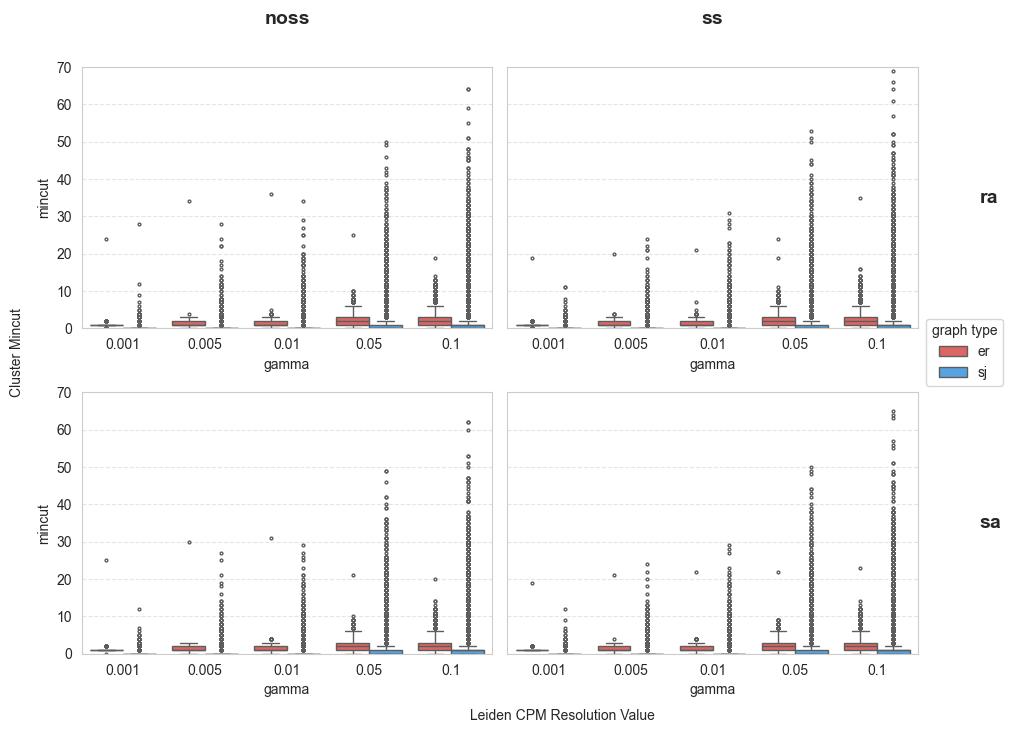

In [75]:

root = "data"

#  • Lista exata dos 8 experimentos
experiments = [
    "7_6_fmf_standard_no_ss_ra_new_pubmed",
    "7_6_fmf_standard_no_ss_sa_new_pubmed",
    "7_6_fmf_standard_ss_ra_new_pubmed",
    "7_6_fmf_standard_ss_sa_new_pubmed",
    "7_7_ecc7_no_ss_ra_new_pubmed_er",
    "7_7_ecc7_no_ss_sa_new_pubmed_er",
    "7_7_ecc7_ss_ra_new_pubmed_er",
    "7_7_ecc7_ss_sa_new_pubmed_er",
]

exp_paths = build_exp_paths(root, experiments)
plot_cluster_mincut(exp_paths)


In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_cluster_size_scatter(file_paths):
    code_to_gamma = {
        "0001": 0.001,
        "0005": 0.005,
        "001":  0.01,
        "005":  0.05,
        "01":   0.1,
    }
    gamma_order = [str(v) for v in code_to_gamma.values()]

    all_rows = []

    for fp in file_paths:
        try:
            # Pega o código do gamma a partir do nome do arquivo
            code = os.path.basename(fp).split('_')[-1].replace('.csv', '')
            
            # Lê o arquivo CSV
            df = pd.read_csv(fp)

            # Converte a coluna 'gamma' para string
            df['gamma'] = df['gamma'].astype(str).str.replace('_', '.')
            
            all_rows.append(df)

        except FileNotFoundError:
            print(f"Aviso: Arquivo não encontrado em {fp}. Pulando.")
            continue
        except Exception as e:
            print(f"Erro ao processar o arquivo {fp}: {e}")
            continue

    if not all_rows:
        print("Nenhum dado encontrado após o carregamento.")
        return

    big_df = pd.concat(all_rows, ignore_index=True)
    big_df["gamma"] = pd.Categorical(big_df["gamma"], categories=gamma_order, ordered=True)

    # Inferir 'env' e 'tag2' a partir da coluna 'experiment'
    # 'ra' ou 'sa'
    big_df['env'] = big_df['experiment'].apply(lambda x: 'ra' if '_ra_' in x else 'sa')
    # 'tag2' (sj ou er)
    big_df['tag2'] = big_df['experiment'].apply(lambda x: 'er' if '_er' in x else 'sj')

    # Filtrar apenas os superstars específicos
    superstar_fits = [10000, 100000, 1000000]
    big_superstars = big_df[big_df['ss_fit'].isin(superstar_fits)].copy()

    # Mapear ss_fit para nomes de rótulo
    fit_to_label = {
        10000: 'SS Fit 10K',
        100000: 'SS Fit 100K',
        1000000: 'SS Fit 1M'
    }
    big_superstars['ss_fit_label'] = big_superstars['ss_fit'].map(fit_to_label)
    superstar_fit_order = [fit_to_label[f] for f in superstar_fits]

    sns.set_style("whitegrid")
    
    # Agora teremos 2 linhas (env) e 2 colunas (tag2: sj, er)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    facets = [
        ("ra", "sj"), # Linha 1, Coluna 1: RA, SJ
        ("ra", "er"), # Linha 1, Coluna 2: RA, ER
        ("sa", "sj"), # Linha 2, Coluna 1: SA, SJ
        ("sa", "er"), # Linha 2, Coluna 2: SA, ER
    ]
    
    palette = sns.color_palette("viridis", n_colors=len(superstar_fits))

    for ax, (env, tag2) in zip(axes.flatten(), facets):
        # Filtra por ambiente e tipo de grafo (sj/er)
        sub = big_superstars[(big_superstars.env == env) & (big_superstars.tag2 == tag2)]

        if not sub.empty:
            sns.scatterplot(
                data=sub,
                x="gamma", 
                y="size", 
                hue="ss_fit_label",
                hue_order=superstar_fit_order,
                palette=palette,
                ax=ax,
                s=100,
                alpha=0.8
            )
            
        # ax.set_ylim(0, 20000)
        ax.set_yscale("log")
        ax.grid(axis="y", which="major", linestyle="--", alpha=0.5)
        ax.set_xlabel("")
        ax.set_ylabel("")

        leg = ax.get_legend()
        if leg:
            leg.set_title("Superstar Fitness")
            leg.set_bbox_to_anchor((1.05, 1))
            leg.loc = 'upper left'
            leg.set_frame_on(False)


    # Rótulos e anotações globais
    fig.text(0.5, 0.04, "Leiden CPM Resolution Value", ha="center", fontsize=12)
    fig.text(0.04, 0.5, "Cluster Size", va="center", rotation="vertical", fontsize=12)
    
    # Anotações para as linhas (Ambientes)
    for row_idx, env_label in enumerate(["ra","sa"]):
        ax = axes[row_idx, 1]
        ax.annotate(text=env_label, xy=(1.1, 0.5), xycoords="axes fraction",
                     ha="left", va="center", fontsize=14, fontweight="bold", annotation_clip=False)

    # Anotações para as colunas (Tipos de Grafo)
    for col_idx, tag2_label in enumerate(["sj","er"]):
        ax = axes[0, col_idx]
        ax.annotate(text=tag2_label, xy=(0.5, 1.15), xycoords="axes fraction",
                     ha="center", va="bottom", fontsize=14, fontweight="bold", annotation_clip=False)

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.suptitle("Cluster Size for Superstars by Gamma, Environment, and Graph Type", y=0.98, fontsize=16, fontweight='bold')
    plt.show()

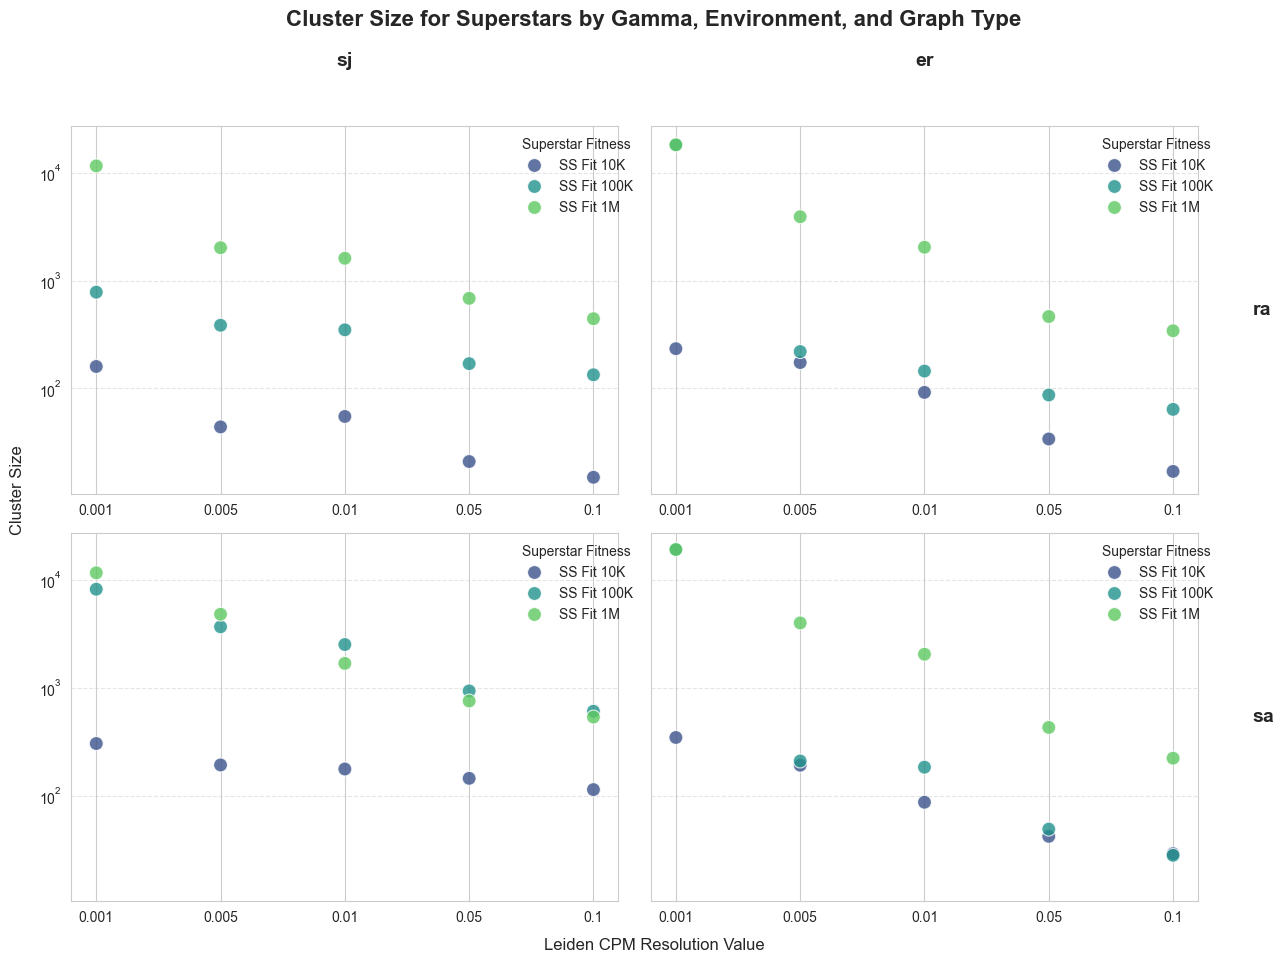

In [92]:

experiments = [
    "data/standards_sj_er_new_pubmed/ss_cluster_gamma_0001.csv",
    "data/standards_sj_er_new_pubmed/ss_cluster_gamma_0005.csv",
    "data/standards_sj_er_new_pubmed/ss_cluster_gamma_001.csv",
    "data/standards_sj_er_new_pubmed/ss_cluster_gamma_005.csv",
    "data/standards_sj_er_new_pubmed/ss_cluster_gamma_01.csv"
]


plot_cluster_size_scatter(experiments)


In [ ]:
df_metrics_ra = pd.read_csv("data/er/7_7_ecc7_ss_ra_new_pubmed_er/output/clustering_metrics_0001.csv")
df_ss_ra = pd.read_csv("data/standards_sj_er_new_pubmed/ss_cluster_gamma_0001.csv")
df_ss_ra = df_ss_ra.query("experiment == '7_7_ecc7_ss_ra_new_pubmed_er'")
ss_ids = df_ss_ra["cluster_id"].to_list()
df_metrics_ra = df_metrics_ra.query(f"cluster_id in {ss_ids}")
df_metrics_ra = df_metrics_ra[["cluster_id","size","mincut","avg_recency_w","avg_pa_w","avg_fitness_w","avg_fitness","seeds","agents"]]
df_metrics_ra['experiment'] = "er_ss_ra"


,cluster_id,size,mincut,avg_recency_w,avg_pa_w,avg_fitness_w,avg_fitness,seeds,agents,experiment
1864,2903,234,1,0.3479,0.3390,0.3132,62.2906,91,143,er_ss_ra
3439,0,18230,19,0.2839,0.4189,0.2972,74.9682,0,18230,er_ss_ra


In [105]:
df_metrics_sa = pd.read_csv("data/er/7_7_ecc7_ss_sa_new_pubmed_er/output/clustering_metrics_0001.csv")
df_ss_sa = pd.read_csv("data/standards_sj_er_new_pubmed/ss_cluster_gamma_0001.csv")
df_ss_sa = df_ss_sa.query("experiment == '7_7_ecc7_ss_sa_new_pubmed_er'")
ss_ids = df_ss_sa["cluster_id"].to_list()
df_metrics_sa = df_metrics_sa.query(f"cluster_id in {ss_ids}")
df_metrics_sa = df_metrics_sa[["cluster_id","size","mincut","avg_recency_w","avg_pa_w","avg_fitness_w","avg_fitness","seeds","agents"]]
df_metrics_sa['experiment'] = "er_ss_sa"
df_metrics_sa.head()


,cluster_id,size,mincut,avg_recency_w,avg_pa_w,avg_fitness_w,avg_fitness,seeds,agents,experiment
688,1150,347,1,0.3333,0.3333,0.3333,41.8732,155,192,er_ss_sa
3594,0,19258,19,0.3333,0.3333,0.3333,71.2696,0,19258,er_ss_sa


In [107]:
#SJ
df_metrics_ra = pd.read_csv("data/sj/7_6_fmf_standard_ss_ra_new_pubmed/output/clustering_metrics_0001.csv")
df_ss_ra = pd.read_csv("data/standards_sj_er_new_pubmed/ss_cluster_gamma_0001.csv")
df_ss_ra = df_ss_ra.query("experiment == '7_6_fmf_standard_ss_ra_new_pubmed'")
ss_ids = df_ss_ra["cluster_id"].to_list()
df_metrics_ra = df_metrics_ra.query(f"cluster_id in {ss_ids}")
df_metrics_ra = df_metrics_ra[["cluster_id","size","mincut","avg_recency_w","avg_pa_w","avg_fitness_w","avg_fitness","seeds","agents"]]
df_metrics_ra['experiment'] = "sj_ss_ra"
df_metrics_ra.head()


,cluster_id,size,mincut,avg_recency_w,avg_pa_w,avg_fitness_w,avg_fitness,seeds,agents,experiment
2,0,11616,11,0.3128,0.3430,0.3443,103.9514,346,11270,sj_ss_ra
608,1167,160,1,0.3435,0.3304,0.3261,86.3875,66,94,sj_ss_ra
882,417,783,1,0.3420,0.3504,0.3077,141.1699,369,414,sj_ss_ra


In [109]:
#SJ
df_metrics_sa = pd.read_csv("data/sj/7_6_fmf_standard_ss_sa_new_pubmed/output/clustering_metrics_0001.csv")
df_ss_sa = pd.read_csv("data/standards_sj_er_new_pubmed/ss_cluster_gamma_0001.csv")
df_ss_sa = df_ss_sa.query("experiment == '7_6_fmf_standard_ss_sa_new_pubmed'")
ss_ids = df_ss_sa["cluster_id"].to_list()
df_metrics_sa = df_metrics_sa.query(f"cluster_id in {ss_ids}")
df_metrics_sa = df_metrics_sa[["cluster_id","size","mincut","avg_recency_w","avg_pa_w","avg_fitness_w","avg_fitness","seeds","agents"]]
df_metrics_sa['experiment'] = "sj_ss_sa"
df_metrics_sa.head()


,cluster_id,size,mincut,avg_recency_w,avg_pa_w,avg_fitness_w,avg_fitness,seeds,agents,experiment
2,0,11698,12,0.3333,0.3333,0.3333,103.7765,377,11321,sj_ss_sa
35,1,8243,9,0.3333,0.3333,0.3333,28.7229,297,7946,sj_ss_sa
315,887,305,1,0.3333,0.3333,0.3333,47.8459,146,159,sj_ss_sa
